# Texture Analysis in Satellite Imagery Using Wavelet Transform

This notebook demonstrates how to use the Discrete Wavelet Transform (DWT) to analyze and visualize texture features in satellite images.

## 1. Perform 2D Discrete Wavelet Transform (DWT)

We will use the 'haar' wavelet to decompose the grayscale satellite image into four sub-bands.

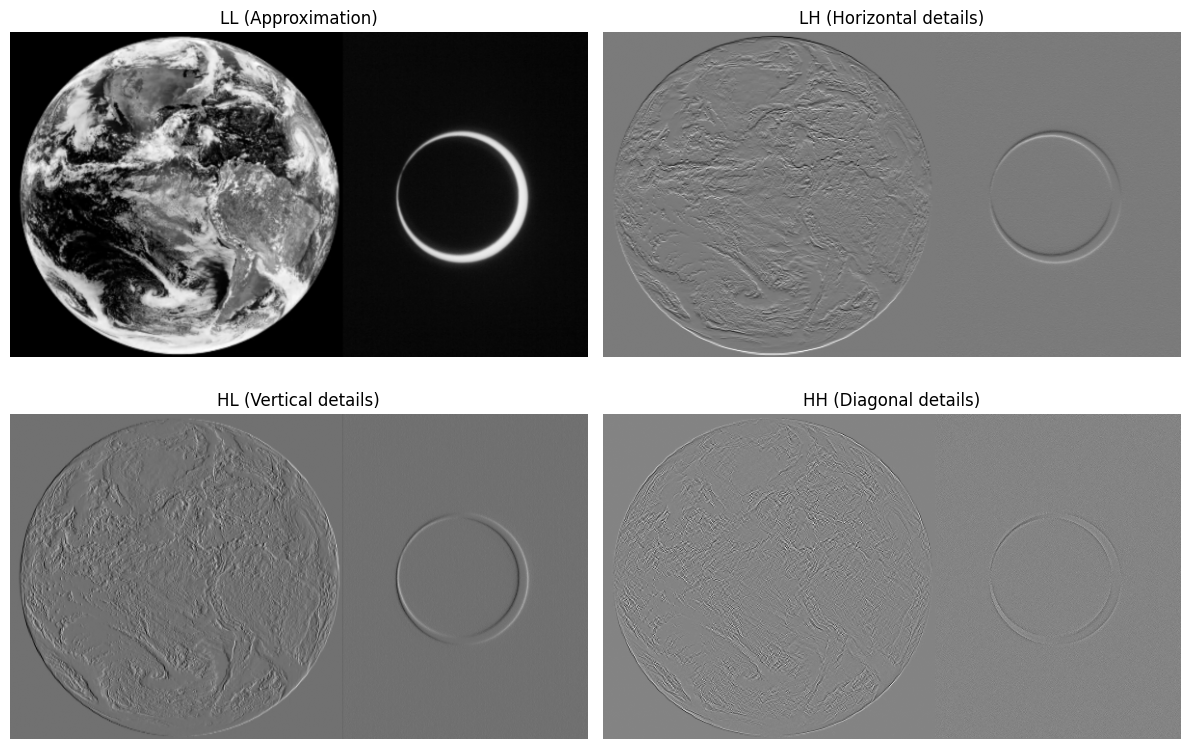

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Load satellite image (replace with your filename if needed)
img = cv2.imread('earth.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise Exception('Image not found!')

# Perform 2D DWT using 'haar' wavelet
coeffs2 = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs2

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(LL, cmap='gray')
plt.title('LL (Approximation)')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(LH, cmap='gray')
plt.title('LH (Horizontal details)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(HL, cmap='gray')
plt.title('HL (Vertical details)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(HH, cmap='gray')
plt.title('HH (Diagonal details)')
plt.axis('off')
plt.tight_layout()

plt.show()

## 2. Reconstruct the Image Using Inverse DWT

We will reconstruct the original image from the sub-bands and compare it visually.

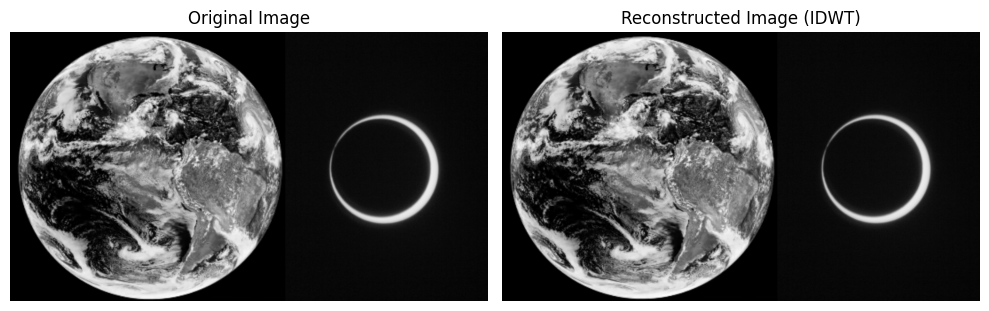

In [4]:
# Reconstruct the image using inverse DWT
reconstructed = pywt.idwt2((LL, (LH, HL, HH)), 'haar')
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title('Reconstructed Image (IDWT)')
plt.axis('off')

plt.tight_layout()

plt.show()

## 3. Interpretation: Sub-band Characteristics and Applications

- **LL (Approximation):** Contains the low-frequency, smooth regions of the image. Useful for general structure and background information.
- **LH (Horizontal details):** Captures horizontal edges and textures, highlighting transitions in the vertical direction. Useful for detecting water boundaries or roads.
- **HL (Vertical details):** Captures vertical edges and textures, highlighting transitions in the horizontal direction. Useful for identifying urban structures or field boundaries.
- **HH (Diagonal details):** Contains high-frequency diagonal information, useful for fine texture and noise analysis.

**Applications:**
- Sub-band decomposition helps in feature extraction (e.g., urban/vegetation/water classification), texture analysis, and image compression (by discarding or quantizing high-frequency bands).
- The reconstructed image closely matches the original, demonstrating the effectiveness of DWT for multi-resolution analysis and lossless compression.